In [1]:
#import libraries 
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Matplotlib is building the font cache; this may take a moment.


In [2]:
#generate synthetic gesture images
np.random.seed(42)

IMG_SIZE = 32

gestures = {
    0:"Fist",
    1:"Palm",
    2:"ThumbsUp",
    3:"Victory",
    4:"Pointing"
}

X = []
y = []

samples_per_class = 300

for label in gestures.keys():

    for _ in range(samples_per_class):

        img = np.random.randint(
            0,
            40,
            (IMG_SIZE, IMG_SIZE)
        )

        if label == 0:
            img[8:24,8:24] += 180

        elif label == 1:
            img[4:28,4:28] += 140

        elif label == 2:
            img[:,14:18] += 180

        elif label == 3:
            img[5:27,10:13] += 180
            img[5:27,19:22] += 180

        elif label == 4:
            img[14:18,:] += 180

        img = np.clip(
            img,
            0,
            255
        )

        X.append(img.flatten())
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)

Dataset Shape: (1500, 1024)


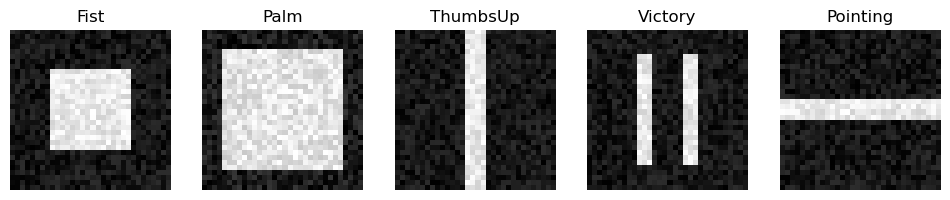

In [3]:
#display gesture samples
plt.figure(figsize=(12,6))

for gesture in range(5):

    index = np.where(y == gesture)[0][0]

    plt.subplot(1,5,gesture+1)

    plt.imshow(
        X[index].reshape(32,32),
        cmap='gray'
    )

    plt.title(
        gestures[gesture]
    )

    plt.axis('off')

plt.show()

In [4]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1200, 1024)
(300, 1024)


In [5]:
#train svm model
model = SVC(

    kernel='rbf',

    gamma='scale'
)

model.fit(

    X_train,

    y_train
)

print("Training Completed")

Training Completed


In [6]:
#prediction
y_pred = model.predict(X_test)

In [7]:
#accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy*100:.2f}%"
)

Accuracy: 100.00%


In [8]:
#classification report
print(

    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Fist",
            "Palm",
            "ThumbsUp",
            "Victory",
            "Pointing"
        ]
    )
)

              precision    recall  f1-score   support

        Fist       1.00      1.00      1.00        60
        Palm       1.00      1.00      1.00        60
    ThumbsUp       1.00      1.00      1.00        60
     Victory       1.00      1.00      1.00        60
    Pointing       1.00      1.00      1.00        60

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



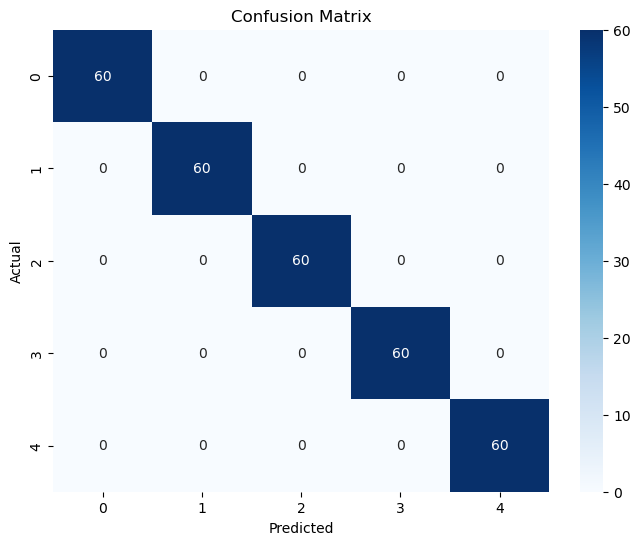

In [9]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    cmap='Blues',

    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

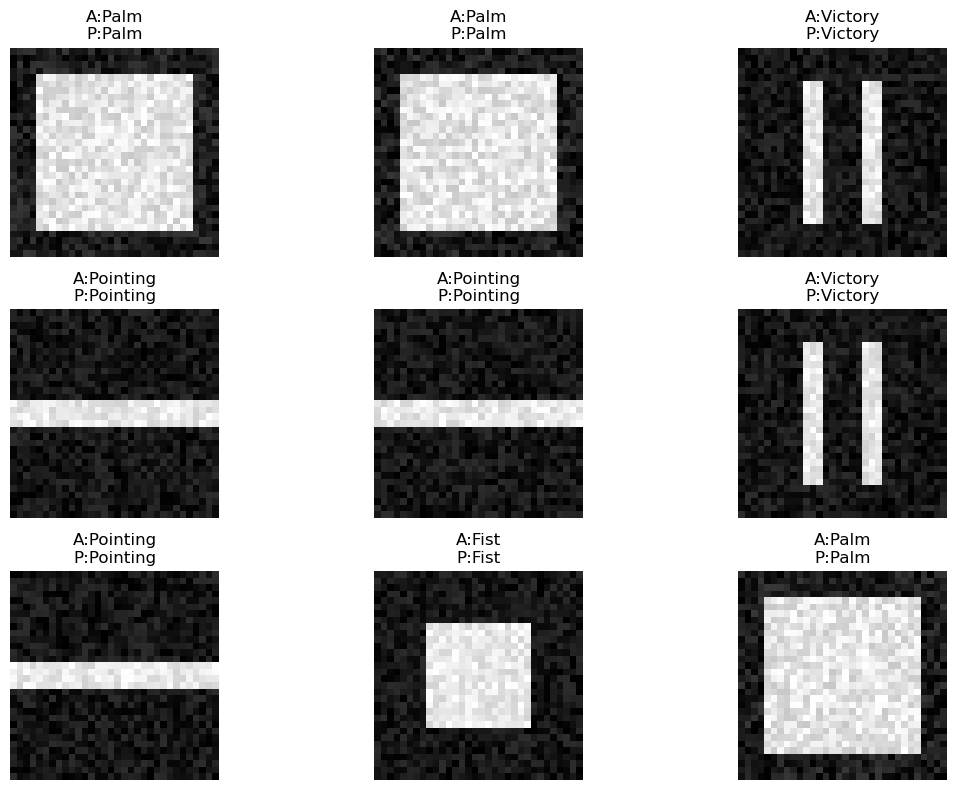

In [10]:
#gesture prediction visualization
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    image = X_test[i].reshape(
        32,
        32
    )

    pred = gestures[
        y_pred[i]
    ]

    actual = gestures[
        y_test[i]
    ]

    plt.imshow(
        image,
        cmap='gray'
    )

    plt.title(
        f"A:{actual}\nP:{pred}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [11]:
#predict new gesture
sample = np.random.randint(
    0,
    40,
    (32,32)
)

sample[14:18,:] += 180

sample = np.clip(
    sample,
    0,
    255
)

prediction = model.predict(
    [sample.flatten()]
)

print(
    "Predicted Gesture:",
    gestures[prediction[0]]
)

Predicted Gesture: Pointing


In [12]:
#result summary
results = pd.DataFrame({

    "Metric":[
        "Accuracy"
    ],

    "Value":[
        accuracy
    ]
})

results

,Metric,Value
0,Accuracy,1.0
